# 👔 MobileNetV3-Small Staff Classifier — Purplle Retail

This notebook trains a **MobileNetV3-Small** binary classifier (staff vs customer) on crops extracted from your CCTV clips, then exports to **ONNX**.

## Prerequisites
1. **Runtime → Change runtime type → GPU (T4)**
2. Complete Notebook 1 first (or have frames already extracted)
3. Your CCTV clips must include staff members wearing identifiable uniforms

## What gets produced
- `mobilenet_staff.onnx` → drop into `models/`
- Target: precision ≥ 0.90, recall ≥ 0.85

## Design Reference
From `design.md §2.5`: Two-signal ensemble — MobileNetV3 + HSV histogram.
The pipeline uses ONNX output for the NN signal and computes HSV Bhattacharyya distance at runtime.

In [1]:
# ============================================================
# CELL 1 — Verify GPU and install dependencies
# ============================================================
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '⚠️  No GPU — switch runtime')

!pip install -q torch torchvision opencv-python-headless scikit-learn matplotlib
import torch
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

Wed Jun  3 23:09:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ============================================================
# CELL 2 - Mount Drive and verify staff_crops from preprocess step
#
# PREREQUISITE: Run 00_preprocess_data.ipynb first.
# That notebook extracted person crops from the billing and entry
# camera clips and saved them to Drive as staff_crops/.
# This notebook reads those crops directly.
# You do NOT need the raw .mp4 clips for this notebook.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Change DRIVE_BASE only if you used a different folder in the preprocess notebook
DRIVE_BASE      = '/content/drive/MyDrive/purplle'
STAFF_CROPS_DIR = os.path.join(DRIVE_BASE, 'staff_crops')

assert os.path.exists(STAFF_CROPS_DIR), (
    f'staff_crops not found at: {STAFF_CROPS_DIR}\n'
    'Ensure 00_preprocess_data.ipynb ran successfully and used the same DRIVE_BASE.'
)

# Expected sub-folders: staff/ and customer/ (created by 00_preprocess_data)
staff_dir    = os.path.join(STAFF_CROPS_DIR, 'staff')
customer_dir = os.path.join(STAFF_CROPS_DIR, 'customer')
n_staff    = len(os.listdir(staff_dir))    if os.path.exists(staff_dir)    else 0
n_customer = len(os.listdir(customer_dir)) if os.path.exists(customer_dir) else 0

print(f'Found staff_crops at: {STAFF_CROPS_DIR}')
print(f'  staff/    : {n_staff} crops')
print(f'  customer/ : {n_customer} crops')
print()
if n_staff < 20:
    print('WARNING: Very few staff crops found. HSV auto-sort may have missed many.')
    print('  -> Open the staff_crops/staff/ folder in Drive and move any misplaced crops.')
    print('  -> Minimum recommended: 50 staff crops for reliable training.')
else:
    print('Crop extraction already completed by 00_preprocess_data.ipynb. Ready to train.')

Mounted at /content/drive
Found staff_crops at: /content/drive/MyDrive/purplle/staff_crops
  staff/    : 231 crops
  customer/ : 984 crops

Crop extraction already completed by 00_preprocess_data.ipynb. Ready to train.


In [3]:
# ============================================================
# CELL 3 - Copy staff_crops from Drive to local /content/crops
#
# Drive reads are slow. Copy once to local SSD for faster training.
# ============================================================
import shutil, time

LOCAL_CROPS = '/content/crops'

if os.path.exists(LOCAL_CROPS):
    shutil.rmtree(LOCAL_CROPS)

print(f'Copying {STAFF_CROPS_DIR} -> {LOCAL_CROPS} ...')
t0 = time.time()
shutil.copytree(STAFF_CROPS_DIR, LOCAL_CROPS)
print(f'Done in {time.time()-t0:.0f}s')

n_staff    = len(os.listdir(os.path.join(LOCAL_CROPS, 'staff')))
n_customer = len(os.listdir(os.path.join(LOCAL_CROPS, 'customer')))
print(f'Local crops: staff={n_staff} | customer={n_customer}')
print()
print('IMPORTANT: Review /content/crops/staff/ in the file browser.')
print('  Move any misclassified customer crops out before proceeding to training.')

Copying /content/drive/MyDrive/purplle/staff_crops -> /content/crops ...
Done in 36s
Local crops: staff=231 | customer=984

IMPORTANT: Review /content/crops/staff/ in the file browser.
  Move any misclassified customer crops out before proceeding to training.


In [4]:
# ============================================================
# CELL 7 — Balance dataset and create train/val splits
# ============================================================
import glob, os, random, shutil

random.seed(42)

staff_crops    = glob.glob('/content/crops/staff/*.jpg')
customer_crops = glob.glob('/content/crops/customer/*.jpg')

print(f'Staff crops:    {len(staff_crops)}')
print(f'Customer crops: {len(customer_crops)}')

# Balance: downsample majority class to 3x minority
min_count = min(len(staff_crops), len(customer_crops))
max_count = min(min_count * 3, max(len(staff_crops), len(customer_crops)))

random.shuffle(staff_crops)
random.shuffle(customer_crops)
staff_crops    = staff_crops[:max_count]
customer_crops = customer_crops[:max_count]

print(f'\nAfter balancing:')
print(f'  Staff: {len(staff_crops)}, Customer: {len(customer_crops)}')

for split in ['train', 'val']:
    for cls in ['staff', 'customer']:
        os.makedirs(f'/content/dataset_cls/{split}/{cls}', exist_ok=True)

def split_and_copy(crop_list, class_name, train_ratio=0.8):
    split_idx = int(len(crop_list) * train_ratio)
    for i, path in enumerate(crop_list):
        split = 'train' if i < split_idx else 'val'
        shutil.copy(path, f'/content/dataset_cls/{split}/{class_name}/{os.path.basename(path)}')

split_and_copy(staff_crops, 'staff')
split_and_copy(customer_crops, 'customer')

for split in ['train', 'val']:
    for cls in ['staff', 'customer']:
        n = len(glob.glob(f'/content/dataset_cls/{split}/{cls}/*.jpg'))
        print(f'  {split}/{cls}: {n} images')

Staff crops:    231
Customer crops: 984

After balancing:
  Staff: 231, Customer: 693
  train/staff: 184 images
  train/customer: 554 images
  val/staff: 47 images
  val/customer: 139 images


In [5]:
# ============================================================
# CELL 8 — Build DataLoaders with augmentation
# ============================================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Augmentation strategy from design.md §8.2
train_transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder('/content/dataset_cls/train', transform=train_transform)
val_dataset   = datasets.ImageFolder('/content/dataset_cls/val',   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f'Classes: {train_dataset.classes}')  # ['customer', 'staff']
print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

# Class index mapping (important for interpreting model output)
CLASS_TO_IDX = train_dataset.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
STAFF_CLASS_IDX = CLASS_TO_IDX['staff']
print(f'Staff class index: {STAFF_CLASS_IDX}')

Classes: ['customer', 'staff']
Train batches: 24
Val batches:   6
Staff class index: 1


In [6]:
# ============================================================
# CELL 9 — Build MobileNetV3-Small model
# From design.md §8.2: Replace classifier head with Linear(576, 2)
# ============================================================
import torch
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load pretrained MobileNetV3-Small
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Replace classifier head: 576 → 2 (customer / staff)
# MobileNetV3-Small last adaptive pooling output: 576 features
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 2)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable:,}')

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 117MB/s]


Total params:     1,519,906
Trainable params: 1,519,906


Epoch   5/30 | Train Loss: 0.1521 | Val Loss: 0.0019 | Val Acc: 1.0000
Epoch  10/30 | Train Loss: 0.0310 | Val Loss: 0.0462 | Val Acc: 0.9892
Epoch  15/30 | Train Loss: 0.0072 | Val Loss: 0.0331 | Val Acc: 0.9892
Epoch  20/30 | Train Loss: 0.0123 | Val Loss: 0.0114 | Val Acc: 0.9946
Epoch  25/30 | Train Loss: 0.0088 | Val Loss: 0.0022 | Val Acc: 1.0000
Epoch  30/30 | Train Loss: 0.3385 | Val Loss: 0.0037 | Val Acc: 1.0000

Best val accuracy: 1.0000


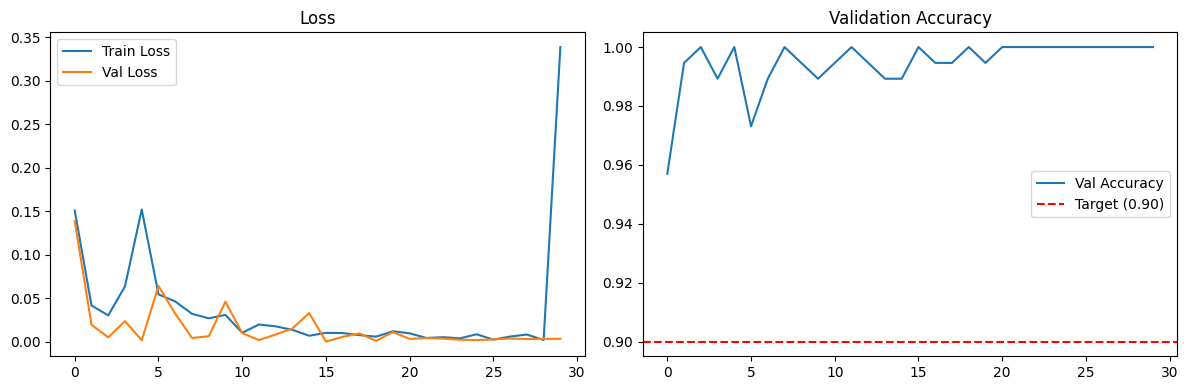

In [7]:
# ============================================================
# CELL 10 — Training loop
# From design.md §8.2: 30 epochs, AdamW lr=1e-3, cosine annealing
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30)

EPOCHS = 30
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total
    scheduler.step()

    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/mobilenet_staff_best.pth')

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'Train Loss: {history["train_loss"][-1]:.4f} | '
              f'Val Loss: {history["val_loss"][-1]:.4f} | '
              f'Val Acc: {val_acc:.4f}')

print(f'\nBest val accuracy: {best_val_acc:.4f}')

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].legend(); axes[0].set_title('Loss')
axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='Target (0.90)')
axes[1].legend(); axes[1].set_title('Validation Accuracy')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=100)
plt.show()

In [8]:
# ============================================================
# CELL 11 — Evaluate precision and recall
# Targets: precision ≥ 0.90, recall ≥ 0.85 (design.md §2.5)
# ============================================================
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model
model.load_state_dict(torch.load('/content/mobilenet_staff_best.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print('Classification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=list(IDX_TO_CLASS[i] for i in range(2))
))

# Extract staff class metrics
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, pos_label=STAFF_CLASS_IDX, average='binary'
)

print(f'Staff Precision: {precision:.4f}  (target: ≥ 0.90)')
print(f'Staff Recall:    {recall:.4f}   (target: ≥ 0.85)')
print(f'Staff F1-Score:  {f1:.4f}')

if precision >= 0.90 and recall >= 0.85:
    print('\n✅  Both targets met! Proceeding to ONNX export.')
else:
    if precision < 0.90:
        print('⚠️  Precision below target. Review staff crops for misclassified customers.')
    if recall < 0.85:
        print('⚠️  Recall below target. Add more staff crop variety (different angles/lighting).')

Classification Report:
              precision    recall  f1-score   support

    customer       1.00      1.00      1.00       139
       staff       1.00      1.00      1.00        47

    accuracy                           1.00       186
   macro avg       1.00      1.00      1.00       186
weighted avg       1.00      1.00      1.00       186

Staff Precision: 1.0000  (target: ≥ 0.90)
Staff Recall:    1.0000   (target: ≥ 0.85)
Staff F1-Score:  1.0000

✅  Both targets met! Proceeding to ONNX export.


In [10]:
!pip install onnxscript
# ============================================================
# CELL 12 — Export to ONNX
# Output shape: (1, 2) → [customer_prob, staff_prob]
# The pipeline reads probs[1] as staff probability
# ============================================================
import torch
import torch.nn.functional as F

model.load_state_dict(torch.load('/content/mobilenet_staff_best.pth', map_location='cpu'))
model.eval().cpu()

# Wrap model to output softmax probabilities
class StaffClassifierWithSoftmax(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model

    def forward(self, x):
        return F.softmax(self.model(x), dim=1)

export_model = StaffClassifierWithSoftmax(model)
export_model.eval()

# Export input: (1, 3, 256, 128) — batch of BGR crops resized to 256x128
dummy_input = torch.randn(1, 3, 256, 128)

ONNX_PATH = '/content/mobilenet_staff.onnx'
torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_PATH,
    opset_version=17,
    input_names=['input'],
    output_names=['probs'],   # shape: (batch, 2) — [customer_prob, staff_prob]
    dynamic_axes={'input': {0: 'batch_size'}, 'probs': {0: 'batch_size'}},
)

print(f'ONNX model exported to: {ONNX_PATH}')

# Verify
import onnx
m = onnx.load(ONNX_PATH)
onnx.checker.check_model(m)
print('✅  ONNX model validation passed')
print(f'Output[1] = staff probability (used by pipeline)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 16.5 MB/s eta 0:00:00


/tmp/ipykernel_8663/1783558475.py:29: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0603 23:16:14.289000 8663 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `StaffClassifierWithSoftmax([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `StaffClassifierWithSoftmax([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model exported to: /content/mobilenet_staff.onnx
✅  ONNX model validation passed
Output[1] = staff probability (used by pipeline)


In [12]:
!pip install onnxruntime
# ============================================================
# CELL 13 — Benchmark ONNX inference on CPU
# ============================================================
import onnxruntime as ort
import numpy as np
import time

session = ort.InferenceSession('/content/mobilenet_staff.onnx', providers=['CPUExecutionProvider'])

dummy = np.random.rand(1, 3, 256, 128).astype(np.float32)

# Warmup
for _ in range(10):
    session.run(None, {'input': dummy})

# Benchmark
N = 100
t0 = time.perf_counter()
for _ in range(N):
    session.run(None, {'input': dummy})
elapsed = time.perf_counter() - t0
avg_ms = (elapsed / N) * 1000

print(f'Average inference: {avg_ms:.2f} ms per crop')
print(f'Throughput:        {1000/avg_ms:.0f} crops/sec')
print('Target: < 5ms per crop (design.md §2.5)')

if avg_ms < 5:
    print('✅  Meets <5ms target on CPU')
else:
    print('⚠️  Above 5ms target. Model is still usable but may limit pipeline throughput.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 99.4 MB/s eta 0:00:00
Average inference: 2.33 ms per crop
Throughput:        430 crops/sec
Target: < 5ms per crop (design.md §2.5)
✅  Meets <5ms target on CPU


In [13]:
# ============================================================
# CELL 14 — Save to Google Drive and download
# ============================================================
import shutil, os

drive_dest = '/content/drive/MyDrive/purplle/models/mobilenet_staff.onnx'
os.makedirs(os.path.dirname(drive_dest), exist_ok=True)
shutil.copy('/content/mobilenet_staff.onnx', drive_dest)

print(f'✅  Saved to Google Drive: {drive_dest}')
print()
print('Next steps:')
print('  1. Download mobilenet_staff.onnx from Google Drive')
print('  2. Place it in: models/mobilenet_staff.onnx')
print('  3. Restart the vision pipeline:')
print('     docker compose restart vision-pipeline')
print('  The staff_classifier.py will auto-detect and use the ONNX model.')
print('  Without it, the pipeline falls back to HSV-only classification.')

from google.colab import files
files.download('/content/mobilenet_staff.onnx')

✅  Saved to Google Drive: /content/drive/MyDrive/purplle/models/mobilenet_staff.onnx

Next steps:
  1. Download mobilenet_staff.onnx from Google Drive
  2. Place it in: models/mobilenet_staff.onnx
  3. Restart the vision pipeline:
     docker compose restart vision-pipeline
  The staff_classifier.py will auto-detect and use the ONNX model.
  Without it, the pipeline falls back to HSV-only classification.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📊 Training Summary

| Item | Value |
|------|-------|
| Base model | MobileNetV3-Small (ImageNet pretrained) |
| Classifier head | `Linear(576, 2)` — [customer, staff] |
| Input size | `(1, 3, 256, 128)` — person crop, normalised |
| Output | `softmax([customer_prob, staff_prob])` |
| Target precision | ≥ 0.90 |
| Target recall | ≥ 0.85 |
| Target speed | < 5ms/crop on CPU |
| Output file | `mobilenet_staff.onnx` → place in `models/` |

### How the pipeline uses this model:
```python
# In staff_classifier.py:
outputs = onnx_session.run(None, {input_name: crop_tensor})
staff_prob = outputs[0][0][1]   # Index 1 = staff class
is_staff = (staff_prob > 0.70) AND (bhattacharyya_dist < 0.30)
```

### Troubleshooting low precision:
- Check that staff crops don't include customers in Purplle-coloured clothing
- Increase `STAFF_FRAC_THR` in Cell 6 to reduce false positives in auto-sort
- Add negative examples: customers in similar colours

### Troubleshooting low recall:
- Staff may not always wear full uniform (partial coverage, jackets off)
- Add crops of staff from different angles and lighting conditions
- Lower the `NN_STAFF_THRESHOLD` from 0.70 to 0.60 in `staff_classifier.py`